In [1]:
import re
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset


In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

PROJECT_ROOT = Path("/Users/zhengzikun/Desktop/MLDS414/final_project")
sys.path.append(str(PROJECT_ROOT))


In [3]:
!pip -q install datasets==2.20.0 pandas numpy matplotlib seaborn tqdm scikit-learn wordcloud textblob

In [4]:
for subdir in [
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/samples",
    "outputs/models",
]:
    (PROJECT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

multi_lexsum = load_dataset(
    "allenai/multi_lexsum",
    name="v20230518",
    trust_remote_code=True
)

def build_multilexsum_dataframe(dataset_dict):
    rows = []

    for split_name, split_data in dataset_dict.items():
        for item in split_data:
            metadata = item.get("case_metadata", {}) or {}
            sources = item.get("sources", []) or []

            rows.append({
                "split": split_name,
                "case_id": item.get("id"),
                "source_text": "\n\n".join(sources),
                "num_source_docs": len(sources),
                "ref_long": item.get("summary/long"),
                "ref_short": item.get("summary/short"),
                "ref_tiny": item.get("summary/tiny"),
                "case_metadata": metadata,
                "case_name": metadata.get("case_name"),
                "case_type": metadata.get("case_type"),
                "class_action_sought": metadata.get("class_action_sought"),
                "filing_year": metadata.get("filing_year"),
                "case_ongoing": metadata.get("case_ongoing"),
                "prevailing_party": metadata.get("prevailing_party"),
            })

    return pd.DataFrame(rows)

df = build_multilexsum_dataframe(multi_lexsum)

print("Shape:", df.shape)
display(df["split"].value_counts())
display(df.head(2))


Shape: (4539, 14)


split
train         3177
test           908
validation     454
Name: count, dtype: int64

,split,case_id,source_text,num_source_docs,ref_long,ref_short,ref_tiny,case_metadata,case_name,case_type,class_action_sought,filing_year,case_ongoing,prevailing_party
0,train,EE-AL-0045,Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 1 of 6\n\nIN\n\nTHE\n\nUNITED\n\nSTATES\n\nDISTRICT\n\nFILD COUR T\n\nP19\n\n.05\n\nNl\n\nel\n\n.s\n\nFOR THE SOUTHERN DISTRICT OF ALABAMA\n\nSOUTHERN DIVISION\n\nEQUAL EMPLOYMENT OPPORTUNIT...,4,"On September 15, 2005, the Equal Employment Opportunity Commission (EEOC) filed suit against House of Philadelphia, Inc., on behalf of an employee who was allegedly fired because she was pregnant. Seeking monetary and injunctive relief for the em...","Equal Employment Opportunity Commission brought a Title VII sex discrimination case against House of Philadelphia, Inc., on behalf of an employee who was allegedly fired because she was pregnant. The EEOC sought monetary and injunctive relief for...",None,"{'case_name': 'EEOC v. House of Philadelphia Center, Inc.', 'case_type': 'Equal Employment', 'filing_date': '2005-09-15', 'filing_year': '2005', 'case_ongoing': 'No', 'case_ongoing_record_time': '2022-05-19', 'closing_year': '2010', 'order_start_...","EEOC v. House of Philadelphia Center, Inc.",Equal Employment,No,2005,No,Plaintiff
1,train,PB-NJ-0003,"Case 3:05-cv-01784-SRC-JJH Document 2 Filed 05/19/2005 Page 1 of 22\n\nNEW JERSEY PROTECTION AND ADVOCACY, INC. BY: WILLIAM EMMETT DWYER, ESQ. (WD 6894)\nHELEN C. DODICK, ESQ. (HD 4960) 210 SOUTH BROAD STREET, 3RD FLOOR TRENTON, NEW JERSEY 08608 ...",4,"NOTE: This is one of three identically named cases in the Clearinghouse. For the 2005 case generally challenging the unnecessary institutionalization of individuals with disabilities in New Jersey, see <a href=""http://www.clearinghouse.net/detai...","The case was brought by a non-profit organization against the state of New Jersey seeking declaratory and injunctive relief. On July 29, 2009, the parties reached a settlement in favor of the plaintiff.",None,"{'case_name': 'Disability Rights New Jersey v. Velez', 'case_type': 'Public Benefits / Government Services', 'filing_date': '2005-04-05', 'filing_year': '2005', 'case_ongoing': 'No', 'case_ongoing_record_time': '2022-05-19', 'closing_year': '2017...",Disability Rights New Jersey v. Velez,Public Benefits / Government Services,No,2005,No,Plaintiff


In [5]:
def clean_for_summary(text):
    """
    Light cleaning for summarization and display.

    This preserves casing, party names, court names, case citations, and statute references.
    It mainly removes OCR/page noise and normalizes whitespace.
    """
    if pd.isna(text) or text is None:
        return ""

    text = str(text)

    # Remove common page markers while keeping the actual legal content.
    text = re.sub(r"Page\s+\d+\s+of\s+\d+", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"Document\s+\d+(-\d+)?\s+Filed\s+\d{1,2}/\d{1,2}/\d{2,4}", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"Case\s+\d+:\d{2}-cv-[\w\-]+", " ", text, flags=re.IGNORECASE)

    # Normalize common OCR spacing artifacts.
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\s+\n", "\n", text)
    text = re.sub(r"\n\s+", "\n", text)

    # Final compacting for model input while preserving sentence structure.
    text = re.sub(r"\s+", " ", text).strip()

    return text


def clean_for_modeling(text):
    """
    Stronger cleaning for TF-IDF classification.

    This starts with clean_for_summary(), then lowercases and normalizes noisy docket IDs.
    Legally meaningful statute references are preserved in normalized form.
    """
    text = clean_for_summary(text)

    # Lowercase for bag-of-words / TF-IDF modeling.
    text = text.lower()

    # Normalize docket/case number patterns rather than removing all legal references.
    text = re.sub(r"\bno\.\s*\d+:\d{2}-cv-[\w\-]+\b", " docket_id ", text)
    text = re.sub(r"\bcase\s+\d+:\d{2}-cv-[\w\-]+\b", " docket_id ", text)

    # Normalize statute formatting but preserve the legal signal.
    text = re.sub(r"u\.s\.c\.", "usc", text)
    text = re.sub(r"§", " section ", text)

    # Remove repeated punctuation artifacts.
    text = re.sub(r"[_]{2,}", " ", text)
    text = re.sub(r"[-]{3,}", " ", text)
    text = re.sub(r"\.{3,}", " ", text)

    # Keep letters, numbers, and useful legal symbols normalized as text.
    text = re.sub(r"\s+", " ", text).strip()

    return text


def word_count(text):
    if pd.isna(text) or text is None:
        return 0
    return len(str(text).split())


# Quick smoke test
test_text = """
Case 1:20-cv-01234 Document 2 Filed 01/01/2020 Page 1 of 5

UNITED STATES DISTRICT COURT
Plaintiff filed suit under 42 U.S.C. § 1983. No. 1:20-cv-01234.
"""

print("Summary cleaning:")
print(clean_for_summary(test_text))

print("\nModeling cleaning:")
print(clean_for_modeling(test_text))


Summary cleaning:
UNITED STATES DISTRICT COURT Plaintiff filed suit under 42 U.S.C. § 1983. No. 1:20-cv-01234.

Modeling cleaning:
united states district court plaintiff filed suit under 42 usc section 1983. docket_id .


In [6]:
from tqdm.auto import tqdm
tqdm.pandas()

df["cleaned_text_summary"] = df["source_text"].progress_apply(clean_for_summary)
df["cleaned_text_modeling"] = df["source_text"].progress_apply(clean_for_modeling)

df["raw_word_count"] = df["source_text"].apply(word_count)
df["summary_clean_word_count"] = df["cleaned_text_summary"].apply(word_count)
df["modeling_clean_word_count"] = df["cleaned_text_modeling"].apply(word_count)

cleaning_stats = df[
    ["raw_word_count", "summary_clean_word_count", "modeling_clean_word_count"]
].describe().T

display(cleaning_stats)

display(
    df[[
        "case_id",
        "case_name",
        "case_type",
        "raw_word_count",
        "summary_clean_word_count",
        "modeling_clean_word_count"
    ]].head()
)

  0%|          | 0/4539 [00:00<?, ?it/s]

  0%|          | 0/4539 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
raw_word_count,4539.0,61538.587574,145513.077494,961.0,8964.5,24546.0,61792.0,3565130.0
summary_clean_word_count,4539.0,60475.635603,143328.414583,937.0,8822.0,24086.0,60577.5,3540195.0
modeling_clean_word_count,4539.0,60472.894470,143303.679287,935.0,8822.5,24088.0,60575.5,3537520.0


,case_id,case_name,case_type,raw_word_count,summary_clean_word_count,modeling_clean_word_count
0,EE-AL-0045,"EEOC v. House of Philadelphia Center, Inc.",Equal Employment,4897,4793,4800
1,PB-NJ-0003,Disability Rights New Jersey v. Velez,Public Benefits / Government Services,23805,22913,22924
2,EE-FL-0136,United States v. Palm Beach County,Equal Employment,6522,6381,6376
3,EE-CA-0305,Wynne v. McCormick & Schmick's Seafood Restaraunts Inc.,Equal Employment,58302,57072,57063
4,NH-NJ-0002,"U.S. v. Mercer County, New Jersey",Nursing Home Conditions,15612,15166,15143


### Cleaning impact

The cleaning step only slightly reduces total word count because it is intentionally conservative. Legal citations, party names, statute references, and case facts are preserved. This is important because over-cleaning legal text could remove signals needed for summarization and classification.

In [7]:
example_indices = [0, 1, 2]

for idx in example_indices:
    row = df.iloc[idx]

    print("=" * 100)
    print(f"Case ID: {row['case_id']}")
    print(f"Case Name: {row['case_name']}")
    print(f"Case Type: {row['case_type']}")
    print("-" * 100)

    print("\nRAW TEXT SAMPLE:")
    print(row["source_text"][:1200])

    print("\nCLEANED FOR SUMMARY SAMPLE:")
    print(row["cleaned_text_summary"][:1200])

    print("\nCLEANED FOR MODELING SAMPLE:")
    print(row["cleaned_text_modeling"][:1200])
    print()

Case ID: EE-AL-0045
Case Name: EEOC v. House of Philadelphia Center, Inc.
Case Type: Equal Employment
----------------------------------------------------------------------------------------------------

RAW TEXT SAMPLE:
Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 1 of 6

IN

THE

UNITED

STATES

DISTRICT

FILD COUR T

P19

.05

Nl

el

.s

FOR THE SOUTHERN DISTRICT OF ALABAMA

SOUTHERN DIVISION

EQUAL EMPLOYMENT OPPORTUNITY ]

COMMISSION, ]

] Plaintiff, ] Civil Action No. OSS- 0'53a -~

v.

]

]
COMPLAINT

] HOUSE OF PHILADELPHIA CENTER, INC . ]

JURY TRIAL DEMAND

Defendant .

]
]
] ]

NATURE OF THE ACTION This is an action under Title VII of the Civil Rights Act of 1964 and Title I of the Civil Rights Act of 1991 to correct unlawful employment practices on the basis of sex and to provide appropriate relief to Sharonda Griffin who was adversely affected by such practices . The Commission alleges that the Defendant discriminated against Sharonda Griffin because of her sex

### Cleaning examples

The cleaning functions reduce repeated filing/page markers and normalize whitespace while preserving legally meaningful content. The summary-cleaned text keeps casing and legal references for summarization, while the modeling-cleaned text lowercases and normalizes statute symbols for TF-IDF classification.

Some OCR artifacts remain in the source text. This is expected because the dataset contains long legal documents from varied sources, including scanned filings. The cleaning strategy is intentionally conservative to avoid removing party names, statute references, and case facts.

In [8]:
tables_dir = PROJECT_ROOT / "outputs" / "tables"
samples_dir = PROJECT_ROOT / "outputs" / "samples"

# Save metadata + word counts without full text to keep file small.
cleaning_metadata_cols = [
    "split",
    "case_id",
    "case_name",
    "case_type",
    "class_action_sought",
    "num_source_docs",
    "raw_word_count",
    "summary_clean_word_count",
    "modeling_clean_word_count",
]

df[cleaning_metadata_cols].to_csv(
    tables_dir / "cleaning_metadata_light.csv",
    index=False
)

# Save a small text sample for later review.
sample_cleaned_cols = [
    "split",
    "case_id",
    "case_name",
    "case_type",
    "class_action_sought",
    "source_text",
    "cleaned_text_summary",
    "cleaned_text_modeling",
    "ref_long",
    "ref_short",
    "ref_tiny",
]

df[sample_cleaned_cols].head(20).to_csv(
    samples_dir / "cleaned_sample_20_cases.csv",
    index=False
)

print("Saved cleaning metadata and cleaned text sample.")
print("cleaning_metadata_light rows:", len(df[cleaning_metadata_cols]))
print("cleaned_sample_20_cases rows:", len(df[sample_cleaned_cols].head(20)))


Saved cleaning metadata and cleaned text sample.
cleaning_metadata_light rows: 4539
cleaned_sample_20_cases rows: 20


Top case types used:


case_type
Equal Employment                         1579
Immigration and/or the Border             523
Prison Conditions                         424
Jail Conditions                           303
Public Benefits / Government Services     288
Name: count, dtype: int64

,case_type,rank,term,tfidf_score
0,Equal Employment,1,employment,0.313782
1,Equal Employment,2,eeoc,0.215976
2,Equal Employment,3,discrimination,0.186199
3,Equal Employment,4,employees,0.184253
4,Equal Employment,5,commission,0.168312
5,Equal Employment,6,equal,0.152832
6,Equal Employment,7,vii,0.135285
7,Equal Employment,8,opportunity,0.131467
8,Equal Employment,9,equal employment,0.130288
9,Equal Employment,10,employment opportunity,0.114897


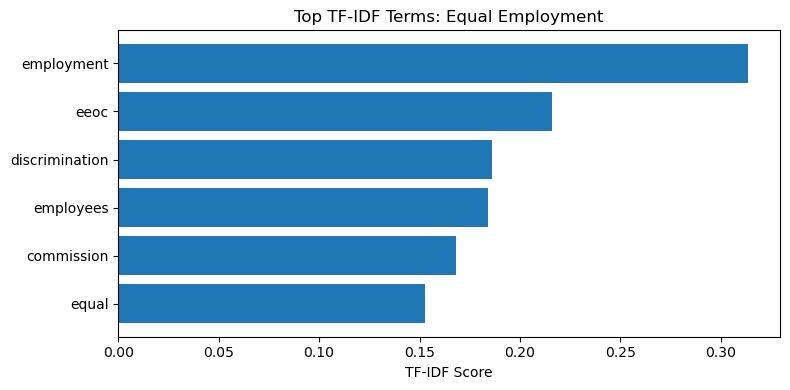

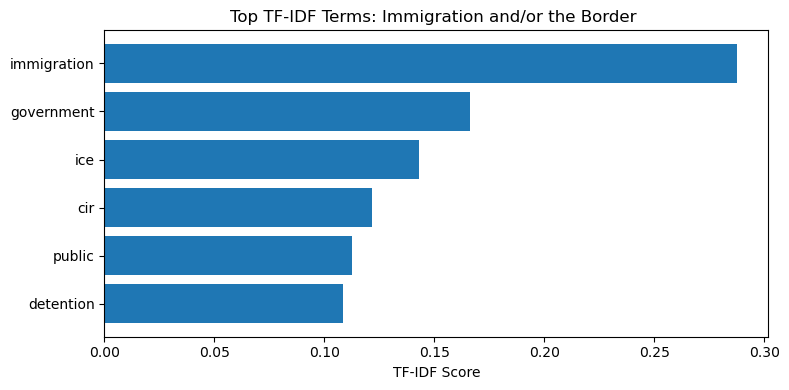

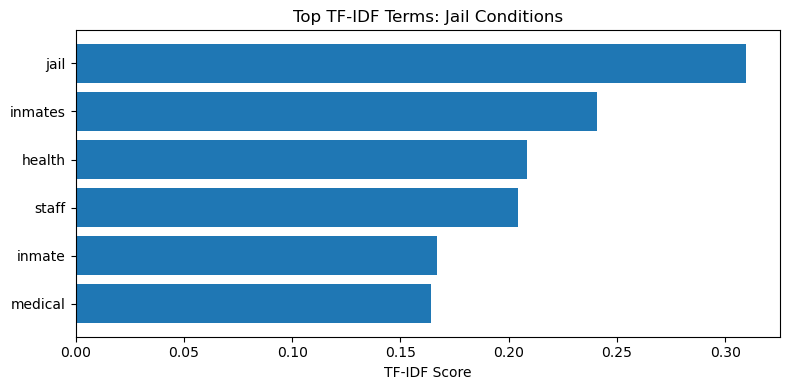

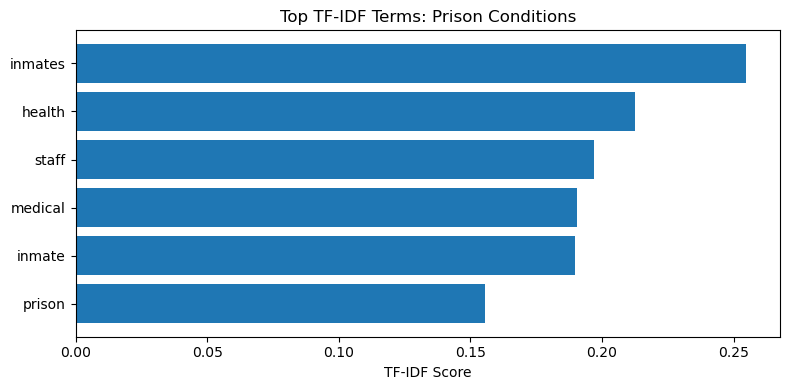

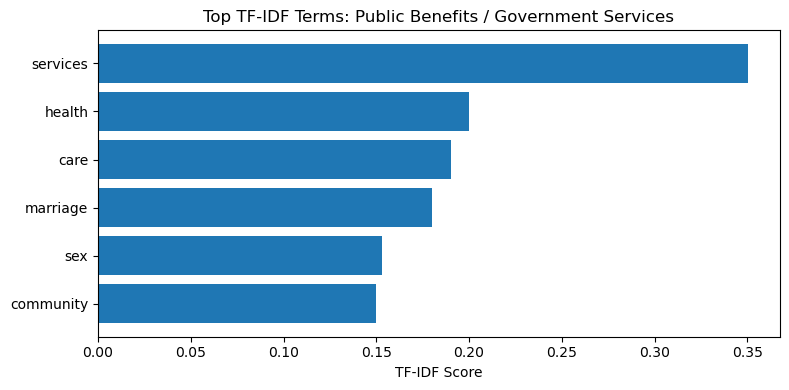

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

legal_stopwords = {
    # court / filing structure
    "court", "courts", "district", "division", "southern", "northern", "eastern", "western",
    "united", "states", "state", "federal", "county", "city",
    "case", "cases", "civil", "action", "actions", "matter", "proceeding", "proceedings",
    "document", "documents", "doc", "filed", "filing", "entered", "docket", "docket_id",
    "page", "pages", "line", "lines", "paragraph", "paragraphs", "exhibit", "exhibits",
    "attachment", "attachments", "appendix", "record", "records",

    # parties / roles
    "plaintiff", "plaintiffs", "defendant", "defendants", "petitioner", "petitioners",
    "respondent", "respondents", "appellant", "appellee", "claimant", "claimants",
    "party", "parties", "class", "classes", "member", "members",

    # attorneys / court actors
    "attorney", "attorneys", "counsel", "lawyer", "lawyers", "esq", "firm",
    "judge", "judges", "magistrate", "clerk", "officer", "officers",

    # common legal documents / motions
    "complaint", "complaints", "amended", "answer", "answers", "motion", "motions",
    "brief", "briefs", "memorandum", "declaration", "affidavit", "notice", "notices",
    "order", "orders", "opinion", "judgment", "injunction", "stipulation",
    "settlement", "agreement", "decree", "consent", "trial", "hearing", "appeal",

    # legal boilerplate verbs / nouns
    "allege", "alleged", "alleges", "alleging", "allegation", "allegations",
    "claim", "claims", "claimed", "claiming", "seeking", "seek", "seeks",
    "requested", "request", "requests", "relief", "remedy", "remedies",
    "jurisdiction", "venue", "standing", "cause", "causes",
    "violation", "violations", "violated", "violates", "violate",
    "pursuant", "therefore", "wherefore", "hereby", "herein", "therein",
    "thereof", "hereto", "hereunder", "forth", "set", "said",

    # legal/statutory boilerplate
    "law", "laws", "legal", "statute", "statutes", "section", "sections",
    "usc", "u.s.c", "cfr", "code", "rule", "rules", "act", "acts",
    "title", "titles", "subsection", "subsections", "amended",

    # generic court/process terms
    "grant", "granted", "deny", "denied", "dismiss", "dismissed", "dismissal",
    "summary", "certification", "certified", "certify",
    "approved", "approval", "issued", "ordered",
    "pending", "closed", "ongoing", "final", "preliminary",
    "temporary", "permanent",

    # generic high-frequency words in legal docs
    "person", "persons", "individual", "individuals", "including", "include", "includes",
    "based", "basis", "respect", "regarding", "related", "relating",
    "following", "prior", "subsequent", "within", "without", "among",
    "provided", "provide", "provides", "required", "requires", "require",
    "failure", "failed", "fail", "right", "rights",

    # noisy OCR / formatting tokens often seen in filings
    "www", "http", "https", "com", "org", "pdf", "html",
    "nbsp", "amp", "quot", "id", "cv", "inc", "llc",

    # other
    "shall", "address", "noticed", "notice", "new", "time"
}

combined_stopwords = list(ENGLISH_STOP_WORDS.union(legal_stopwords))

# Use top 5 case types for interpretability.
top_case_types = df["case_type"].value_counts().head(5).index.tolist()
df_top = df[df["case_type"].isin(top_case_types)].copy()

print("Top case types used:")
display(df_top["case_type"].value_counts())

# Combine text within each case type.
grouped_text = (
    df_top
    .groupby("case_type")["cleaned_text_modeling"]
    .apply(lambda texts: " ".join(texts.astype(str).tolist()))
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=combined_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b"  # removes pure numbers and very short tokens
)

tfidf_matrix = vectorizer.fit_transform(grouped_text)
terms = np.array(vectorizer.get_feature_names_out())

top_terms_rows = []

for i, case_type in enumerate(grouped_text.index):
    scores = tfidf_matrix[i].toarray().ravel()
    top_indices = scores.argsort()[::-1][:12]

    for rank, idx in enumerate(top_indices, start=1):
        top_terms_rows.append({
            "case_type": case_type,
            "rank": rank,
            "term": terms[idx],
            "tfidf_score": scores[idx]
        })

top_terms_df = pd.DataFrame(top_terms_rows)

display(top_terms_df)

top_terms_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "tfidf_top_terms_by_case_type.csv",
    index=False
)

# Compact visualization: top 6 terms per case type
for case_type in grouped_text.index:
    subset = top_terms_df[top_terms_df["case_type"] == case_type].head(6).sort_values("tfidf_score")

    plt.figure(figsize=(8, 4))
    plt.barh(subset["term"], subset["tfidf_score"])
    plt.title(f"Top TF-IDF Terms: {case_type}")
    plt.xlabel("TF-IDF Score")
    plt.tight_layout()

    safe_name = (
        case_type.lower()
        .replace("/", "_")
        .replace(" ", "_")
        .replace("-", "_")
        .replace(".", "")
    )
    plt.savefig(
        PROJECT_ROOT / "outputs" / "figures" / f"tfidf_terms_{safe_name}.png",
        dpi=150
    )
    plt.show()


Top bigrams:


,ngram,count
0,mental health,83573
1,pro hac,51696
2,hac vice,51391
3,use force,36475
4,health care,35314
5,equal employment,32258
6,official capacity,31617
7,employment opportunity,28456
8,special master,27775
9,opportunity commission,26703


Top trigrams:


,ngram,count
0,pro hac vice,51333
1,equal employment opportunity,28101
2,employment opportunity commission,26275
3,department homeland security,13941
4,appear pro hac,11759
5,uscourts gov cgi,10826
6,gov cgi bin,10780
7,minute entry held,10661
8,behalf similarly situated,10516
9,cgi bin dktrpt,10464


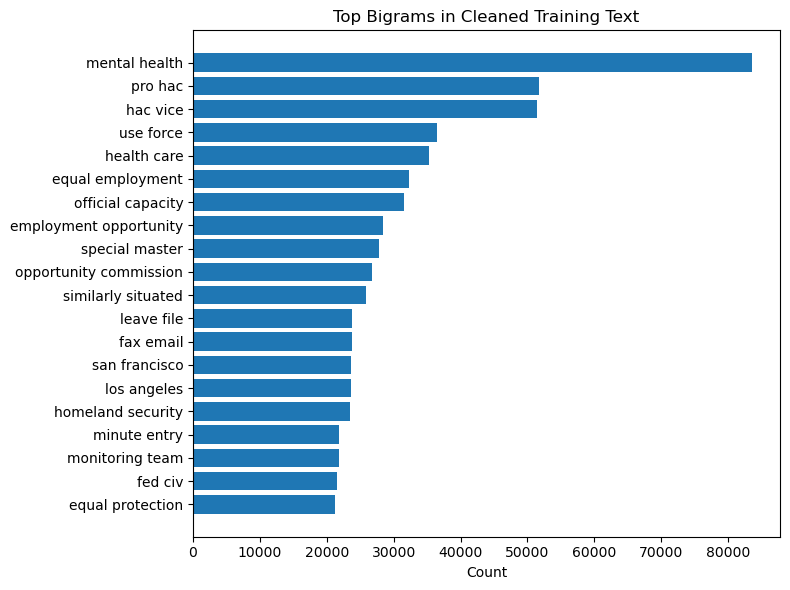

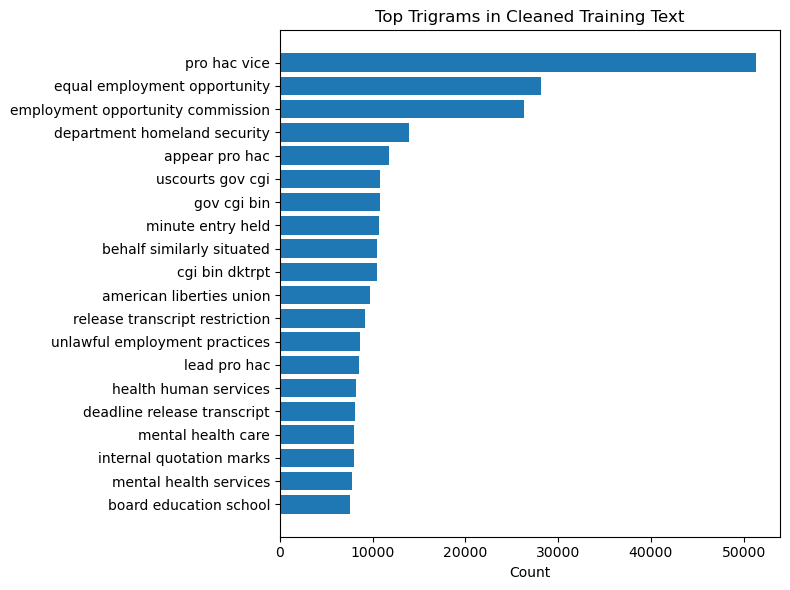

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

train_text = df.loc[df["split"] == "train", "cleaned_text_modeling"].astype(str)

ngram_stopwords = list(ENGLISH_STOP_WORDS.union(legal_stopwords).union({
    "shall", "address", "noticed", "notice", "new", "time"
}))

def get_top_ngrams(texts, ngram_range=(2, 2), top_k=20):
    vectorizer = CountVectorizer(
        stop_words=ngram_stopwords,
        ngram_range=ngram_range,
        min_df=5,
        max_features=5000,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b"
    )

    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    top_idx = counts.argsort()[::-1][:top_k]

    return pd.DataFrame({
        "ngram": terms[top_idx],
        "count": counts[top_idx]
    })


top_bigrams = get_top_ngrams(train_text, ngram_range=(2, 2), top_k=20)
top_trigrams = get_top_ngrams(train_text, ngram_range=(3, 3), top_k=20)

print("Top bigrams:")
display(top_bigrams)

print("Top trigrams:")
display(top_trigrams)

top_bigrams.to_csv(PROJECT_ROOT / "outputs" / "tables" / "top_bigrams.csv", index=False)
top_trigrams.to_csv(PROJECT_ROOT / "outputs" / "tables" / "top_trigrams.csv", index=False)

plt.figure(figsize=(8, 6))
plt.barh(top_bigrams.sort_values("count")["ngram"], top_bigrams.sort_values("count")["count"])
plt.title("Top Bigrams in Cleaned Training Text")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "top_bigrams.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(top_trigrams.sort_values("count")["ngram"], top_trigrams.sort_values("count")["count"])
plt.title("Top Trigrams in Cleaned Training Text")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "top_trigrams.png", dpi=150)
plt.show()


### Key finding: n-grams reveal both legal themes and procedural noise

The n-gram analysis surfaces meaningful legal themes such as `mental health`, `use force`, `health care`, `equal employment`, `homeland security`, and `equal protection`. These phrases reflect major civil-rights topics in the dataset.

At the same time, some frequent n-grams are procedural or filing-related, such as `pro hac vice`, `minute entry`, and `release transcript restriction`. This shows that even after cleaning, legal documents retain structural court language. For this reason, n-gram analysis is useful for exploration, but classification should rely on broader TF-IDF patterns rather than individual phrases alone.

/var/folders/yr/sc_cyb5j1_gcjmw2bh0_8hlc0000gn/T/ipykernel_22240/2871004956.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 20), random_state=42))


Sentiment sample size: 400


,case_id,case_type,class_action_sought,textblob_polarity
2831,CW-NE-0001,Child Welfare,Yes,0.081144
1794,CW-MI-0002,Child Welfare,No,0.013678
2567,CW-OK-0001,Child Welfare,Yes,0.007430
1821,CW-AZ-0001,Child Welfare,Yes,-0.355469
1111,CW-MI-0001,Child Welfare,Yes,0.068933
1126,CW-NY-0011,Child Welfare,Yes,0.007014
3100,CW-MS-0001,Child Welfare,Yes,-0.016106
2660,CW-RI-0002,Child Welfare,Yes,0.000269
1382,CW-KS-0002,Child Welfare,Yes,0.004987
80,CW-MO-0001,Child Welfare,Yes,0.137617


Polarity summary:


count    400.000000
mean       0.013560
std        0.074694
min       -0.355469
25%       -0.025026
50%        0.013029
75%        0.049338
max        0.515625
Name: textblob_polarity, dtype: float64

,count,mean,median,std
case_type,,,,
Child Welfare,20,0.011435,0.013672,0.095264
Intellectual Disability (Facility),20,0.013236,0.016228,0.067964
Public Benefits / Government Services,20,0.020064,0.009538,0.059473
Prison Conditions,20,0.036184,-0.003180,0.132843
Presidential/Gubernatorial Authority,20,-0.054595,-0.051020,0.064516
Policing,20,0.002763,0.014263,0.049908
National Security,20,0.004168,0.008819,0.057499
Mental Health (Facility),20,-0.000747,-0.006932,0.047641
Criminal Justice (Other),20,-0.021190,-0.022542,0.054860


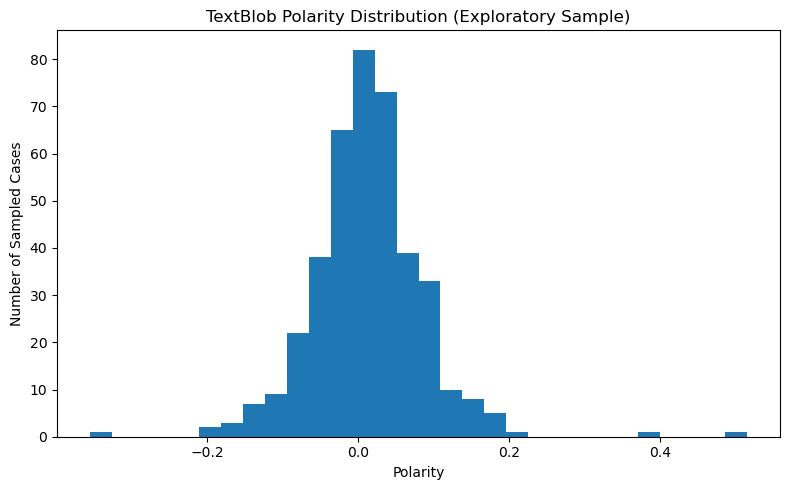

In [11]:
from textblob import TextBlob

# TextBlob can be slow on the full long dataset.
# Use a manageable stratified-ish sample from train split for exploratory analysis.
sentiment_sample = (
    df[df["split"] == "train"]
    .groupby("case_type", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 20), random_state=42))
    .copy()
)

def textblob_polarity(text):
    if pd.isna(text) or text is None or str(text).strip() == "":
        return np.nan
    # Limit length for speed; sentiment is exploratory only.
    return TextBlob(str(text)[:5000]).sentiment.polarity

sentiment_sample["textblob_polarity"] = sentiment_sample["cleaned_text_summary"].apply(textblob_polarity)

print("Sentiment sample size:", sentiment_sample.shape[0])

display(
    sentiment_sample[[
        "case_id",
        "case_type",
        "class_action_sought",
        "textblob_polarity"
    ]].head(10)
)

print("Polarity summary:")
display(sentiment_sample["textblob_polarity"].describe())

# Average polarity by top case types
polarity_by_case_type = (
    sentiment_sample
    .groupby("case_type")["textblob_polarity"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

display(polarity_by_case_type.head(10))

plt.figure(figsize=(8, 5))
plt.hist(sentiment_sample["textblob_polarity"].dropna(), bins=30)
plt.title("TextBlob Polarity Distribution (Exploratory Sample)")
plt.xlabel("Polarity")
plt.ylabel("Number of Sampled Cases")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "textblob_polarity_distribution.png", dpi=150)
plt.show()

polarity_by_case_type.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "textblob_polarity_by_case_type.csv"
)

### Key finding: sentiment is limited for legal text

TextBlob polarity scores are tightly centered around zero, suggesting that general-purpose sentiment analysis does not capture much meaningful variation in formal legal documents. This is expected because legal complaints, orders, and filings use neutral procedural language even when the underlying facts are serious or negative.

For this project, sentiment analysis is included only as an exploratory course technique. It is not used as a legal conclusion or as a core modeling feature.

In [12]:
# Save the full cleaned dataframe as a compressed parquet file.
# This allows Notebook 3 and 4 to load cleaned text directly without re-running cleaning.
cleaned_path = PROJECT_ROOT / "outputs" / "tables" / "multilexsum_cleaned.parquet"

df.to_parquet(cleaned_path, index=False)

print("Saved cleaned dataset.")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Saved file exists:", cleaned_path.exists())

# Quick reload check
df_check = pd.read_parquet(cleaned_path)
print("Reloaded shape:", df_check.shape)
display(df_check[[
    "split",
    "case_id",
    "case_type",
    "class_action_sought",
    "cleaned_text_summary",
    "cleaned_text_modeling"
]].head(2))


Saved cleaned dataset.
Rows: 4539
Columns: 19
Saved file exists: True
Reloaded shape: (4539, 19)


,split,case_id,case_type,class_action_sought,cleaned_text_summary,cleaned_text_modeling
0,train,EE-AL-0045,Equal Employment,No,"IN THE UNITED STATES DISTRICT FILD COUR T P19 .05 Nl el .s FOR THE SOUTHERN DISTRICT OF ALABAMA SOUTHERN DIVISION EQUAL EMPLOYMENT OPPORTUNITY ] COMMISSION, ] ] Plaintiff, ] Civil Action No. OSS- 0'53a -~ v. ] ] COMPLAINT ] HOUSE OF PHILADELPHIA ...","in the united states district fild cour t p19 .05 nl el .s for the southern district of alabama southern division equal employment opportunity ] commission, ] ] plaintiff, ] civil action no. oss- 0'53a -~ v. ] ] complaint ] house of philadelphia ..."
1,train,PB-NJ-0003,Public Benefits / Government Services,No,"NEW JERSEY PROTECTION AND ADVOCACY, INC. BY: WILLIAM EMMETT DWYER, ESQ. (WD 6894) HELEN C. DODICK, ESQ. (HD 4960) 210 SOUTH BROAD STREET, 3RD FLOOR TRENTON, NEW JERSEY 08608 (609) 292-9742 Attorney for Plaintiff UNITED STATES DISTRICT COURT FOR T...","new jersey protection and advocacy, inc. by: william emmett dwyer, esq. (wd 6894) helen c. dodick, esq. (hd 4960) 210 south broad street, 3rd floor trenton, new jersey 08608 (609) 292-9742 attorney for plaintiff united states district court for t..."


## Notebook 2 Summary: Cleaning and Key Text Findings

This notebook created two cleaned versions of the legal case text:

- `cleaned_text_summary`: light cleaning for summarization and display
- `cleaned_text_modeling`: stronger normalization for TF-IDF classification

The cleaning strategy is intentionally conservative. It removes repeated page/filing markers and normalizes whitespace, but it preserves party names, court names, legal citations, statute references, and case facts. This matters because over-cleaning legal documents could remove important signals for both summarization and classification.

### Cleaning impact

The raw source documents are extremely long, and cleaning only slightly reduces word counts. This is expected because the goal is not to aggressively shorten the cases, but to reduce formatting noise while preserving legal content.

### TF-IDF findings

After removing common legal/procedural vocabulary, TF-IDF terms become more interpretable by case type:

- Equal Employment: `employment`, `EEOC`, `discrimination`, `employees`, `Title VII`
- Immigration and/or the Border: `immigration`, `ICE`, `detention`, `enforcement`
- Jail / Prison Conditions: `inmates`, `medical`, `mental health`, `staff`, `treatment`
- Public Benefits / Government Services: `services`, `health`, `care`, `medicaid`, `program`

These results suggest that cleaned legal text contains strong topic-specific signals for predicting `case_type`.

### N-gram findings

N-gram analysis surfaces meaningful legal themes such as `mental health`, `use force`, `health care`, `equal employment`, `homeland security`, and `equal protection`.

Some procedural phrases still appear, such as `pro hac vice`, `minute entry`, and `release transcript restriction`. This shows that legal documents retain court-process language even after cleaning.

### Sentiment finding

TextBlob polarity scores are mostly centered near zero. This suggests that general-purpose sentiment analysis is not very reliable for formal legal documents. Sentiment is included only as an exploratory course technique, not as a legal conclusion or core modeling feature.

### Saved output

The cleaned dataset was saved as:

`outputs/tables/multilexsum_cleaned.parquet`

This file will be used directly in Notebook 3 for summarization and Notebook 4 for classification.